# Gaussian Process Regression: California Housing Prices

**Gaussian Processes Tutorial** <br>

STAT 5440 Final Project <br>

Max Kieff, Mengyue Huang, Alan Wu, Yaohao Zhang, Andrew Zhao

## Motivation

In many real-world problems, we need to make predictions about quantities that vary smoothly across space, time, or some other input domain — but we also need to know *how confident* those predictions are. Classical regression methods like linear regression or even flexible approaches like random forests can give us point estimates, but they often fall short when it comes to principled uncertainty quantification. This is especially important in settings like spatial interpolation, where we want to predict values at unobserved locations based on nearby observations, and where the density of data can vary dramatically across the input space.

**Gaussian Processes (GPs)** offer an elegant, fully Bayesian framework for exactly this kind of problem. A GP defines a distribution over functions, allowing us to encode prior beliefs about smoothness, periodicity, or other structural properties through the choice of kernel (covariance function). Given observed data, the GP posterior provides not just a best-guess prediction at any new input, but a full predictive distribution — capturing both the signal learned from the data and the uncertainty that remains. This makes GPs a natural fit for tasks like geostatistical modeling (kriging), Bayesian optimization, and any regression problem where understanding prediction confidence is as important as the prediction itself.

In this tutorial, we demonstrate GP regression on the **California Housing Prices** dataset. Using geographic coordinates (latitude and longitude) as inputs, we build a spatial model that predicts median house values across the state. Along the way, we will cover the mathematical foundations of GPs, implement models in **Stan** via `cmdstanpy`, and visualize both the predicted price surface and the associated uncertainty — illustrating why GPs are one of the most powerful tools in the Bayesian nonparametric toolkit.

## Table of Contents

1. [Imports](#imports)
2. [Dataset](#dataset)
    - [About the Dataset](#about-the-dataset)
    - [Exploratory Visualization](#exploratory-visualization)
3. [Preprocessing](#preprocessing)
    - [Sampling](#sampling)
    - [Train/Test Split](#train-test-split)
    - [Standardization](#standardization)
4. [Gaussian Process Regression: Spatial-Only Model](#gp-spatial-model)
    - [Model Specification](#model-specification)
    - [Fitting with Stan](#fitting-with-stan)
5. [MCMC Diagnostics](#mcmc-diagnostics)
    - [Convergence Checks](#convergence-checks)
    - [Posterior Summaries](#posterior-summaries)
    - [Posterior Distributions](#posterior-distributions)
6. [Posterior Predictive Evaluation](#posterior-predictive-evaluation)
    - [Observed vs. Predicted](#observed-vs-predicted)
    - [Residual Analysis](#residual-analysis)
    - [Posterior Predictive Check](#posterior-predictive-check)
7. [Spatial Heatmaps](#spatial-heatmaps)
    - [Predictive Mean Surface](#predictive-mean-surface)
    - [Predictive Uncertainty Surface](#predictive-uncertainty-surface)
8. [Exploring Kernel Choices](#kernel-exploration)
    - [Kernel Implementations](#kernel-implementations)
    - [Synthetic Datasets](#synthetic-datasets)
    - [RBF Kernel: Smooth Functions](#rbf-demo)
    - [Periodic Kernel: Repeating Cycles](#periodic-demo)
    - [Matern Kernel: Rough vs. Smooth](#matern-demo)
    - [Linear Kernel: Global Trends](#linear-demo)
    - [Kernel Composition: Addition and Multiplication](#kernel-composition)
    - [Summary of Kernel Properties](#kernel-summary)
9. [Model Extension: Additive Kernel (Spatial + Income)](#model-extension)
    - [Motivation](#motivation)
    - [Kernel Specification](#kernel-specification)
    - [Preprocessing & Fitting](#extension-preprocessing)
    - [Diagnostics](#extension-diagnostics)
    - [Posterior Predictive Evaluation](#extension-evaluation)
    - [Spatial Heatmaps](#extension-heatmaps)
10. [What We Learned](#what-we-learned)

<a id="imports"></a>
### Imports

In [ ]:
# stan do not work with GPU :( , just go with CPU
!pip install pandas cmdstanpy scikit-learn matplotlib 

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from cmdstanpy import CmdStanModel

from cmdstanpy import install_cmdstan
install_cmdstan()

In [6]:
cali_house = pd.read_csv('./data/california_housing.csv')
cali_house.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<a id="dataset"></a>
## Dataset

<a id="about-the-dataset"></a>
### About the Dataset

This dataset contains housing data for various California districts, based on the 1990 U.S. Census. Each row represents a "block group" (a geographically compact area typically containing 600 to 3,000 people). Link: https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html

**Relevance to Gaussian Processes:** This dataset is an excellent candidate for demonstrating **Spatial Interpolation (Kriging)**. Instead of using all demographic features, we can isolate the geographic coordinates (`Longitude` and `Latitude`) to predict the median house value (`MedHouseVal`). A GP can model the spatial correlation of real estate markets, generating a smooth, non-linear topographical heatmap of housing prices across California, while simultaneously mapping out the predictive uncertainty in regions with sparse data.

#### Data Format (`california_housing.csv`) - (20640, 9)
The dataset combines demographic predictor features with geographic coordinates and the target housing value.

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| `MedInc` | Float | Median income in the block group. |
| `HouseAge` | Float | Median house age in the block group. |
| `AveRooms` | Float | Average number of rooms per household. |
| `AveBedrms` | Float | Average number of bedrooms per household. |
| `Population` | Float | Total block group population. |
| `AveOccup` | Float | Average number of household members. |
| `Latitude` | Float | **Spatial Input ($X_2$):** Block group latitude. |
| `Longitude` | Float | **Spatial Input ($X_1$):** Block group longitude. |
| `MedHouseVal` | Float | **Target Variable:** Median house value for California districts (expressed in hundreds of thousands of dollars, e.g., 4.526 = $452,600). |

<a id="exploratory-visualization"></a>
### Exploratory Visualization

The scatter plot below shows all 20,640 block groups, colored by median house value. Spatial clustering is immediately visible: high-value districts concentrate along the coast (Bay Area, Los Angeles, San Diego), while lower values dominate the interior.

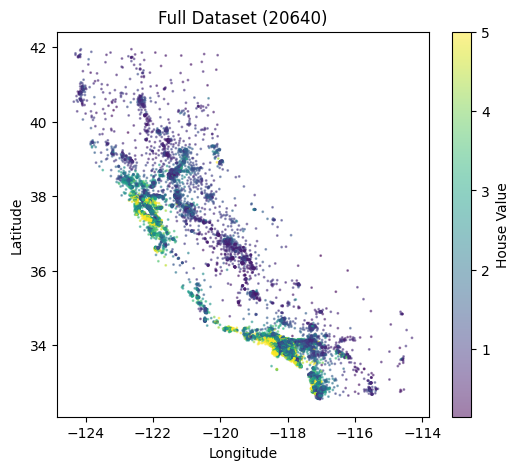

In [7]:
vmin=cali_house['MedHouseVal'].min()
vmax=cali_house['MedHouseVal'].max()

plt.figure(figsize=(6,5))
plt.scatter(
    cali_house['Longitude'],
    cali_house['Latitude'],
    c=cali_house['MedHouseVal'],
    s=1,
    alpha=0.5,
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label='House Value')
plt.title('Full Dataset (20640)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

<a id="preprocessing"></a>
## Preprocessing

<a id="sampling"></a>
### Sampling

To prepare the data for Gaussian Process regression, we extract only the spatial features (`Latitude`, `Longitude`) and the target variable (`MedHouseVal`), then randomly sample 300 data points. This smaller subset keeps exact GP inference with HMC tractable, since the GP covariance matrix scales as $O(n^2)$ in memory and $O(n^3)$ in computation.

In [8]:
df = cali_house[['Latitude', 'Longitude', 'MedHouseVal']].sample(300, random_state=42)
df.isna().sum()

Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

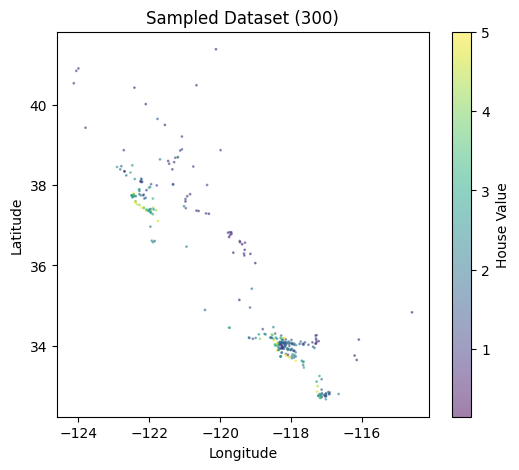

In [9]:
vmin=cali_house['MedHouseVal'].min()
vmax=cali_house['MedHouseVal'].max()

plt.figure(figsize=(6,5))
plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['MedHouseVal'],
    s=1,
    alpha=0.5,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(label='House Value')
plt.title('Sampled Dataset (300)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [10]:
df_stan = df.reset_index(drop=True)

X = df_stan[['Latitude', 'Longitude']].to_numpy()
y = df_stan['MedHouseVal'].to_numpy()

print(X.shape, y.shape)

(300, 2) (300,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<a id="train-test-split"></a>
### Train/Test Split

We split the sampled data into 80% training and 20% test sets, giving us 240 training points for fitting the GP and 60 test points for evaluating predictive performance.

<a id="standardization"></a>
### Standardization

Both the inputs and the target are standardized (zero mean, unit variance). For spatial inputs, this ensures that latitude and longitude contribute equally to the kernel distance calculations. For the target, standardization improves the numerical stability of the Cholesky decomposition used in GP inference and makes the default prior scales more appropriate. We fit the scaler on the training set only and apply it to the test set to avoid data leakage.

In [12]:
# standardize inputs
from sklearn.preprocessing import StandardScaler
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# standardize target
y_mean = y_train.mean()
y_std = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

The choice of kernel determines how similarity between inputs is defined. The RBF kernel assumes smooth variation and strong local correlation, making it appropriate for spatial data such as housing prices.

<a id="gp-spatial-model"></a>
## Gaussian Process Regression: Spatial-Only Model

<a id="model-specification"></a>
### Model Specification

#### Prior over functions
We place a Gaussian Process prior on the latent function:
$$
f(x) \sim \mathcal{GP}(0, k(x, x'))
$$

---

#### Observation model
Observations are modeled as:
$$
y = f(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$

---

#### Kernel function (RBF)
We use the radial basis function (RBF) kernel, which encodes the assumption that nearby points (in $L_2$ distance) should have similar function values:
$$
k(x, x') = \alpha^2 \exp\left(-\frac{\|x - x'\|^2}{2\rho^2}\right)
$$

---

#### Priors on Hyperparameters

We place weakly informative lognormal priors on all hyperparameters to ensure positivity and provide gentle regularization:

$$
\alpha \sim \text{LogNormal}(0,\; 0.5)
$$

$$
\rho \sim \text{LogNormal}(0,\; 0.5)
$$

$$
\sigma \sim \text{LogNormal}(-1,\; 0.5)
$$

The lognormal distribution ensures positivity (all three parameters must be $> 0$) while placing most prior mass in a reasonable range. The prior on $\sigma$ is centered lower (at $e^{-1} \approx 0.37$), reflecting a prior belief that observation noise is moderate relative to the signal. These priors are intentionally diffuse enough to let the data drive inference while preventing the sampler from exploring degenerate regions (e.g., $\rho \to 0$ or $\sigma \to 0$).

---

#### Joint Distribution

Let:
- $X$ denote training inputs
- $X_*$ denote test inputs

Then the joint distribution is:
$$
\begin{bmatrix}
y \\
f_*
\end{bmatrix}
\sim
\mathcal{N}
\left(
0,
\begin{bmatrix}
K(X,X) + \sigma^2 I & K(X, X_*) \\
K(X_*, X) & K(X_*, X_*)
\end{bmatrix}
\right)
$$

---

#### Covariance Matrices

We define:
$$
K = K(X,X) + \sigma^2 I
$$

$$
K_s = K(X, X_*)
$$

$$
K_{ss} = K(X_*, X_*)
$$

---

#### Posterior Predictive Distribution

Conditioning on observed data, the predictive distribution is:
$$
f_* \mid y \sim \mathcal{N}(\mu_*, \Sigma_*)
$$

---

#### Predictive mean
$$
\mu_* = K_s^T K^{-1} y
$$

---

#### Predictive covariance
$$
\Sigma_* = K_{ss} - K_s^T K^{-1} K_s
$$

---

#### Implementation Formulation

Instead of explicitly computing $K^{-1}$, we solve:
$$
\begin{aligned}
\alpha &= K^{-1} y \\
\mu_* &= K_s^T \alpha
\end{aligned}
$$

---

#### Posterior Predictive for Observations

Including observation noise:
$$
y_* \sim \mathcal{N}(\mu_*, \Sigma_* + \sigma^2 I)
$$

---

#### Posterior Predictive Sampling

We draw samples:
$$
y_*^{(s)} \sim \mathcal{N}(\mu_*, \Sigma_* + \sigma^2 I)
$$

---

#### Numerical Stabilization (Jitter)

To ensure numerical stability, we modify:
$$
K \leftarrow K + \epsilon I
$$

where $\epsilon$ is a small constant (e.g., $10^{-8}$).

---

#### Summary

Gaussian Process regression places a prior distribution over functions via a kernel that encodes smoothness and spatial correlation assumptions. The RBF kernel used here has three key hyperparameters: the marginal variance $\alpha^2$ controls the amplitude of function values, the lengthscale $\rho$ governs how quickly correlations decay with distance, and the noise variance $\sigma^2$ captures observation-level noise.

The GP defines a joint multivariate normal distribution over observed and unobserved function values. Conditioning on training data yields closed-form posterior predictive expressions:

- **Predictive mean:** $\mu_* = K_s^T K^{-1} y$ -- a kernel-weighted combination of training outputs, where nearby observations contribute more.
- **Predictive covariance:** $\Sigma_* = K_{ss} - K_s^T K^{-1} K_s$ -- the prior uncertainty reduced by the information provided by training data, so uncertainty shrinks near observed locations and grows in data-sparse regions.

In practice, we avoid forming $K^{-1}$ explicitly. Instead, we compute the Cholesky factorization $K = LL^T$ and solve $L L^T \alpha = y$ by forward and back substitution, giving $O(n^3)$ cost with improved numerical stability. A small jitter $\epsilon I$ is added to the diagonal to prevent ill-conditioning when eigenvalues are near zero.

For fully Bayesian inference, we sample the hyperparameters $(\alpha, \rho, \sigma)$ using Hamiltonian Monte Carlo (HMC) in Stan rather than optimizing point estimates. This marginalizes over hyperparameter uncertainty, producing posterior predictive distributions that account for uncertainty in both the latent function and the kernel parameters.

In [ ]:
stan_data = {
    'N_train': X_train_scaled.shape[0],
    'N_test': X_test_scaled.shape[0],
    'D': X_train_scaled.shape[1],
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train_scaled
}

model = CmdStanModel(stan_file='./stan/gp_california.stan')

fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42
)

<a id="fitting-with-stan"></a>
### Fitting with Stan

We run 4 parallel chains using the default No-U-Turn Sampler (NUTS), with 1000 warmup iterations and 1000 sampling iterations per chain. The warmup phase is used for step-size and mass matrix adaptation, while the sampling phase generates posterior draws for inference.

<a id="mcmc-diagnostics"></a>
## MCMC Diagnostics

After fitting the GP model with HMC in Stan, we assess convergence and sampling quality using standard MCMC diagnostics. These checks ensure that the posterior samples are reliable before interpreting parameter estimates or making predictions.

<a id="convergence-checks"></a>
### Convergence Checks

In [14]:
summary_df = fit.summary()
print(summary_df.columns)

Index(['Mean', 'MCSE', 'StdDev', 'MAD', '5%', '50%', '95%', 'ESS_bulk',
       'ESS_tail', 'ESS_bulk/s', 'R_hat'],
      dtype='str')


In [15]:
params = ['alpha', 'rho', 'sigma']
print(summary_df.loc[params, ['Mean', 'StdDev', 'R_hat', 'ESS_bulk', 'ESS_tail']])

           Mean    StdDev    R_hat  ESS_bulk  ESS_tail
alpha  0.913071  0.232118  1.00287  1316.210   913.059
rho    0.374142  0.275470  1.00244   761.666  1212.900
sigma  0.770362  0.058859  1.00058  1031.990   929.181


In [16]:
sampler_diagnostics = fit.diagnose()
print(sampler_diagnostics)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



#### Diagnostics Interpretation

All standard MCMC diagnostics pass, indicating reliable posterior inference:

- **No divergent transitions**: The sampler did not encounter regions of high curvature in the posterior geometry that would cause biased exploration. Divergences are a common issue in GP models due to the strong correlations between kernel hyperparameters, so their absence here is encouraging.
- **Treedepth satisfactory**: The NUTS sampler's tree depth did not hit its maximum cap, meaning proposals were not prematurely truncated.
- **E-BFMI satisfactory**: The energy Bayesian fraction of missing information is within acceptable bounds, indicating that the sampler's momentum resampling is efficient and there are no problematic energy transitions.
- **$\hat{R} \approx 1.00$ for all parameters**: The rank-normalized split $\hat{R}$ values are close to 1.0, confirming that the four independent chains have converged to the same stationary distribution.
- **Adequate ESS**: The effective sample sizes (ESS_bulk > 750, ESS_tail > 660 for all parameters) indicate sufficient independent draws for reliable posterior summaries and credible intervals.

<a id="posterior-summaries"></a>
### Posterior Summaries

The table below shows the posterior mean, standard deviation, 90% credible interval, and $\hat{R}$ for each kernel hyperparameter. The marginal variance $\alpha$ centers around 0.92, the lengthscale $\rho$ around 0.39 (reflecting relatively short-range spatial correlations on the standardized scale), and the noise standard deviation $\sigma$ around 0.77, indicating substantial observation-level noise relative to the signal.

In [17]:
posterior = fit.draws_pd()

params_of_interest = ['alpha', 'rho', 'sigma']
posterior_summary = summary_df.loc[
    params_of_interest,
    ['Mean', 'StdDev', '5%', '50%', '95%', 'R_hat']
]
print(posterior_summary)

           Mean    StdDev        5%       50%       95%    R_hat
alpha  0.913071  0.232118  0.659632  0.864585  1.326310  1.00287
rho    0.374142  0.275470  0.094901  0.295231  0.978101  1.00244
sigma  0.770362  0.058859  0.667293  0.773779  0.861192  1.00058


<a id="posterior-distributions"></a>
### Posterior Distributions

The histograms below show the marginal posterior distributions for each hyperparameter across all 4,000 posterior draws. These distributions reflect the uncertainty in each parameter after observing the data.

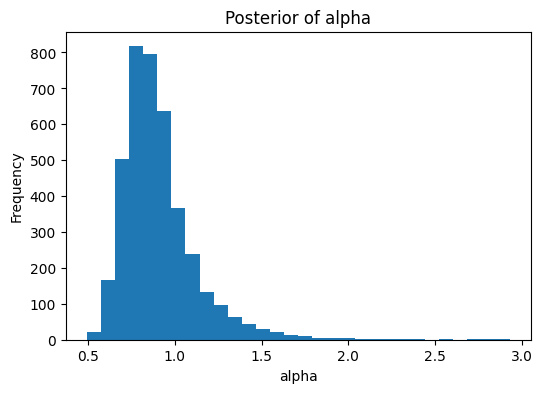

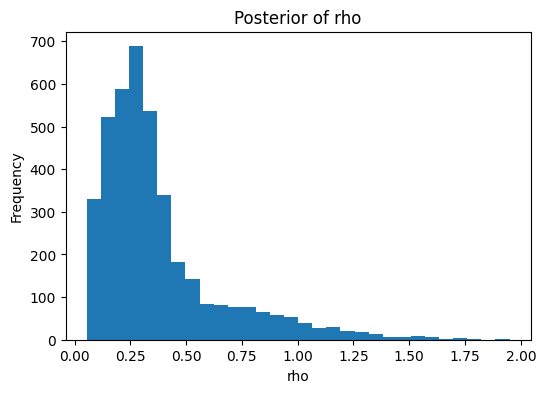

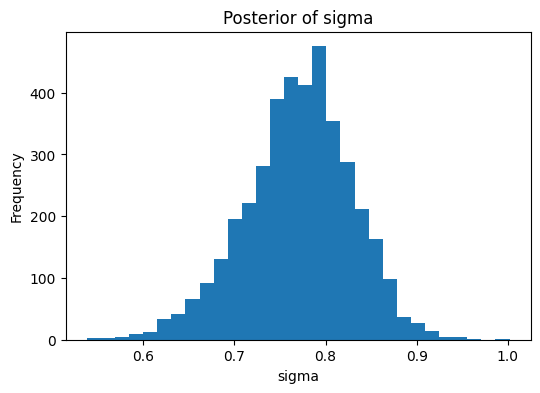

In [18]:
for param in params_of_interest:
    plt.figure(figsize=(6, 4))
    plt.hist(posterior[param], bins=30)
    plt.title(f'Posterior of {param}')
    plt.xlabel(param)
    plt.ylabel('Frequency')
    plt.show()

<a id="posterior-predictive-evaluation"></a>
## Posterior Predictive Evaluation

We now evaluate the model's predictive performance on the held-out test set by examining posterior predictive draws.

In [19]:
# Extract posterior predictive draws for test points
y_test_rep = fit.stan_variable('y_test_rep')   # shape: (draws, N_test)

# Posterior predictive mean on standardized scale
y_test_pred_mean_scaled = y_test_rep.mean(axis=0)

# Transform back to original scale
y_test_pred_mean = y_test_pred_mean_scaled * y_std + y_mean

<a id="observed-vs-predicted"></a>
#### Observed vs. Predicted

The scatter plot of observed versus predicted values shows a positive relationship, indicating that the model captures some of the underlying structure in the data.

However, the predictions tend to be biased toward the mean: lower observed values are overestimated, while higher observed values are underestimated. This pattern suggests that the model is unable to fully capture the variability in housing prices.

This behavior is expected, as the model only uses spatial features (latitude and longitude) and does not incorporate other important predictors such as income, housing characteristics, or local economic factors.

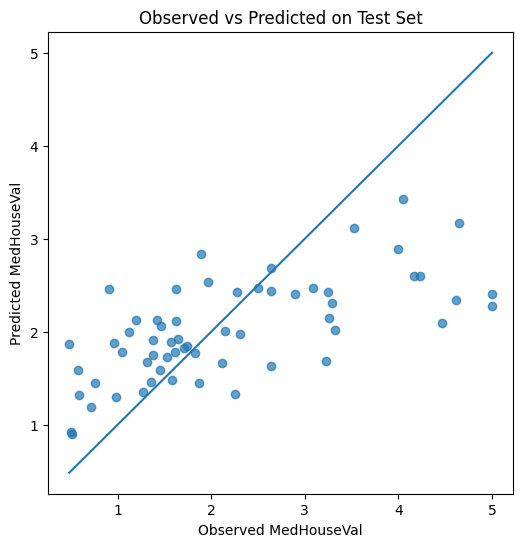

In [20]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_test_pred_mean, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.xlabel('Observed MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Observed vs Predicted on Test Set')
plt.show()

<a id="residual-analysis"></a>
#### Residual Analysis

The residuals are generally centered around zero, indicating that the model is approximately unbiased on average. However, the distribution exhibits a noticeable right tail, suggesting that the model tends to underestimate higher housing prices.

This pattern is consistent with the observed vs. predicted plot, where extreme values are shrunk toward the mean. This behavior reflects the limitations of the model, which relies only on spatial features and cannot fully capture all sources of variability in housing prices.

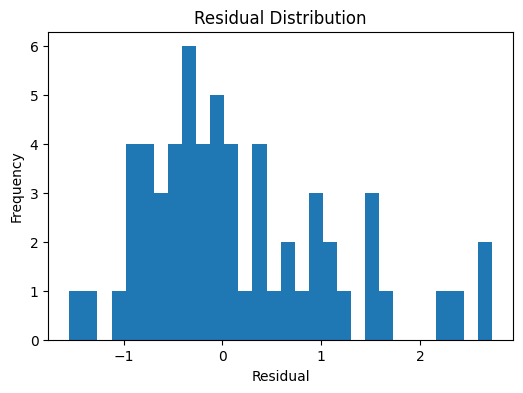

In [21]:
residuals = y_test - y_test_pred_mean

plt.figure(figsize=(6, 4))

plt.hist(residuals, bins=30)

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.show()

<a id="posterior-predictive-check"></a>
#### Posterior Predictive Check

The predictive distributions broadly align with the observed data in the central region, indicating that the model captures the overall structure of the housing price distribution.

However, discrepancies are evident in the tails, particularly for higher values. The model tends to underestimate extreme housing prices, producing smoother distributions with less mass in the upper range.

This suggests that while the Gaussian Process captures large-scale spatial trends, it lacks the flexibility to model sharp variations and extreme values. This limitation is expected given that only spatial features (latitude and longitude) are used in the model.

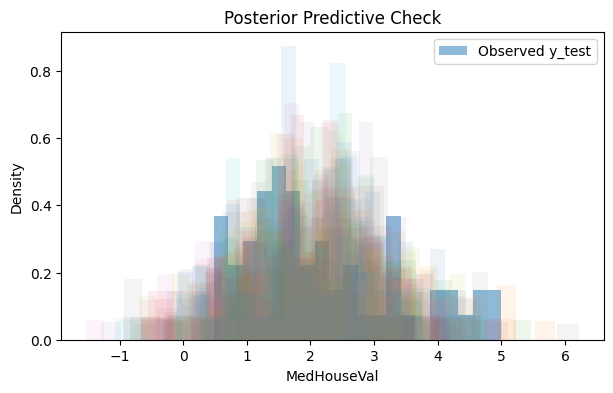

In [22]:
# a few posterior predictive draws and transform back
num_draws_to_plot = 30
draw_indices = np.random.choice(y_test_rep.shape[0], size=num_draws_to_plot, replace=False)

plt.figure(figsize=(7, 4))
plt.hist(y_test, bins=20, alpha=0.5, density=True, label='Observed y_test')

for idx in draw_indices:
    y_rep_original = y_test_rep[idx] * y_std + y_mean
    plt.hist(y_rep_original, bins=20, alpha=0.08, density=True)

plt.xlabel('MedHouseVal')
plt.ylabel('Density')
plt.title('Posterior Predictive Check')
plt.legend()
plt.show()

<a id="spatial-heatmaps"></a>
## Spatial Heatmaps

To visualize the GP's spatial predictions, we construct a dense grid over the latitude-longitude range of the data and compute the posterior predictive mean and standard deviation at each grid point using the posterior mean hyperparameters.

<a id="predictive-mean-surface"></a>
### Predictive Mean Surface

In [23]:
# create a grid
lon_min, lon_max = df['Longitude'].min(), df['Longitude'].max()
lat_min, lat_max = df['Latitude'].min(), df['Latitude'].max()

lon_grid = np.linspace(lon_min, lon_max, 80)
lat_grid = np.linspace(lat_min, lat_max, 80)

lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

X_grid = np.column_stack([lat_mesh.ravel(), lon_mesh.ravel()])
# standardize
X_grid_scaled = x_scaler.transform(X_grid)

In [24]:
# get the values with kernel

# Posterior mean hyperparameters
alpha = 0.918281
rho = 0.389081
sigma = 0.772572
jitter = 1e-5

# Training data in standardized scale
Xtr = X_train_scaled
ytr = y_train_scaled

# Grid data in standardized scale
Xte = X_grid_scaled

def rbf_kernel(X1, X2, alpha, rho):
    # Squared Euclidean distance matrix
    sqdist = (
        np.sum(X1**2, axis=1)[:, None]
        + np.sum(X2**2, axis=1)[None, :]
        - 2 * X1 @ X2.T
    )
    return (alpha**2) * np.exp(-0.5 * sqdist / (rho**2))

# Covariance blocks
K = rbf_kernel(Xtr, Xtr, alpha, rho)
K += (sigma**2 + jitter) * np.eye(len(Xtr))

K_s = rbf_kernel(Xtr, Xte, alpha, rho)
K_ss = rbf_kernel(Xte, Xte, alpha, rho)
K_ss += jitter * np.eye(len(Xte))

# Solve for predictive mean
K_inv_y = np.linalg.solve(K, ytr)
f_mean_scaled = K_s.T @ K_inv_y

# Predictive covariance
K_inv_Ks = np.linalg.solve(K, K_s)
f_cov_scaled = K_ss - K_s.T @ K_inv_Ks

# Convert back to original scale
f_mean = f_mean_scaled * y_std + y_mean
f_sd = np.sqrt(np.clip(np.diag(f_cov_scaled), 0, None)) * y_std

mean_map = f_mean.reshape(lat_mesh.shape)
sd_map = f_sd.reshape(lat_mesh.shape)

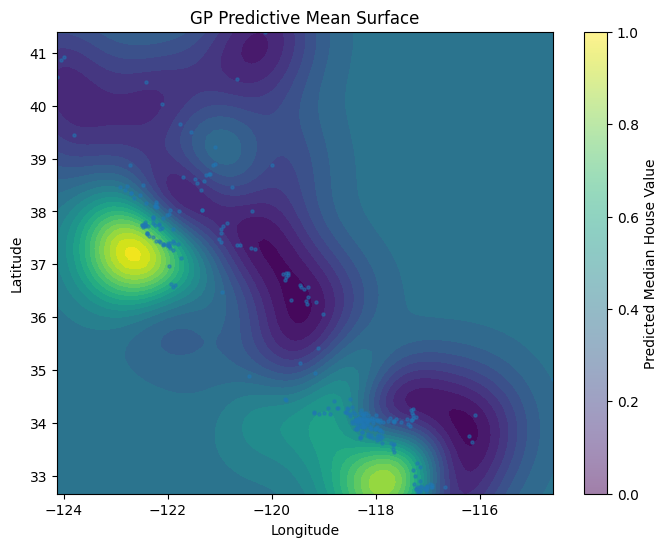

In [25]:
# Predictive Mean Surface heatmap
plt.figure(figsize=(8, 6))

plt.contourf(lon_mesh, lat_mesh, mean_map, levels=30)
plt.scatter(df['Longitude'], df['Latitude'], s=5, alpha=0.5)

plt.colorbar(label='Predicted Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('GP Predictive Mean Surface')
plt.show()

The GP predictive mean surface reveals a smooth, non-linear spatial structure in housing prices across California. High-value regions are concentrated around major urban areas, such as the Bay Area and Southern California, indicating strong spatial dependence.

The smooth transitions between regions reflect the properties of the RBF kernel, which enforces local continuity in the latent function.

<a id="predictive-uncertainty-surface"></a>
### Predictive Uncertainty Surface

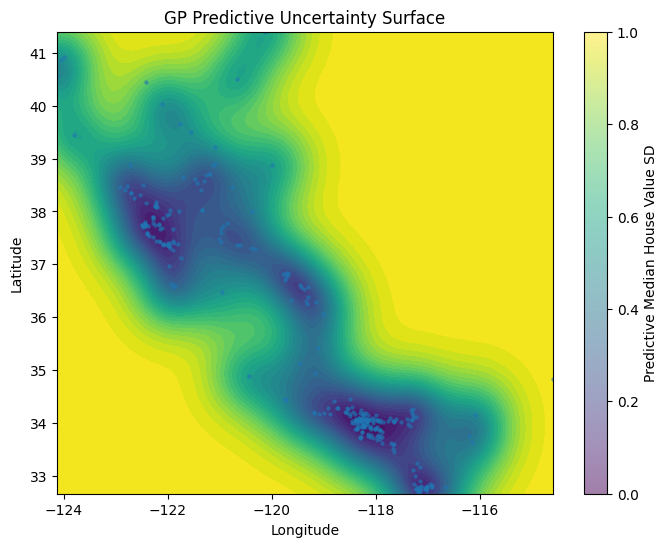

In [26]:
# Uncertainty heatmap
plt.figure(figsize=(8, 6))

plt.contourf(lon_mesh, lat_mesh, sd_map, levels=30)
plt.scatter(df['Longitude'], df['Latitude'], s=5, alpha=0.5)

plt.colorbar(label='Predictive Median House Value SD')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('GP Predictive Uncertainty Surface')
plt.show()

The predictive uncertainty surface shows that uncertainty is lowest in regions with dense observations and increases in areas with sparse or no data. This reflects the Bayesian nature of the Gaussian Process, which naturally quantifies uncertainty based on data availability.

In particular, boundary regions and areas far from observed locations exhibit significantly higher uncertainty, indicating that predictions in these regions should be interpreted with caution.

<a id="kernel-exploration"></a>
## Aside: Exploring Kernel Choices

The kernel (or covariance function) is the most important modeling decision in a Gaussian Process. It encodes our prior assumptions about the structure of the underlying function: Is it smooth? Periodic? Linear? Some combination? We use this exploration to motivate extensions in our model

In the spatial model above, we used the RBF kernel because housing prices vary smoothly over geography. But GPs are far more flexible than this. Below, we implement several common kernels from scratch, fit them to synthetic datasets that highlight their strengths and weaknesses, and build intuition for **kernel composition** -- combining kernels to capture complex structure.

Understanding these kernels motivates the additive kernel extension in the next section, where we combine a spatial RBF with a linear income kernel.

<a id="kernel-implementations"></a>
### Kernel Implementations

We implement four fundamental kernels from scratch using NumPy. Each kernel defines a different notion of similarity between inputs, producing different covariance matrices and therefore different prior assumptions about function behavior.

| Kernel | Formula | Assumption | Best for |
|:---|:---|:---|:---|
| **RBF** | $k(x,x') = \sigma^2 \exp\left(-\frac{\|x-x'\|^2}{2\ell^2}\right)$ | Infinitely smooth, local correlation | Smooth spatial/temporal trends |
| **Matern 3/2** | $k(x,x') = \sigma^2\left(1 + \frac{\sqrt{3}\,r}{\ell}\right)\exp\left(-\frac{\sqrt{3}\,r}{\ell}\right)$ | Once-differentiable, rougher than RBF | Physical processes, wind, terrain |
| **Periodic** | $k(x,x') = \sigma^2 \exp\left(-\frac{2\sin^2(\pi\|x-x'\|/p)}{\ell^2}\right)$ | Exact periodicity with period $p$ | Seasonal/cyclical patterns |
| **Linear** | $k(x,x') = \sigma^2 \, x \cdot x'$ | Global linear trend | Regression, trend components |

In [27]:
# --- Kernel implementations from scratch ---

def kernel_rbf(X1, X2, variance=1.0, lengthscale=1.0):
    """RBF (Squared Exponential) kernel. Infinitely smooth."""
    sqdist = np.sum(X1**2, axis=1)[:, None] + np.sum(X2**2, axis=1)[None, :] - 2 * X1 @ X2.T
    return variance * np.exp(-0.5 * sqdist / lengthscale**2)

def kernel_matern32(X1, X2, variance=1.0, lengthscale=1.0):
    """Matern 3/2 kernel. Once-differentiable (rougher than RBF)."""
    dist = np.sqrt(np.maximum(
        np.sum(X1**2, axis=1)[:, None] + np.sum(X2**2, axis=1)[None, :] - 2 * X1 @ X2.T,
        0.0
    ))
    scaled = np.sqrt(3) * dist / lengthscale
    return variance * (1 + scaled) * np.exp(-scaled)

def kernel_periodic(X1, X2, variance=1.0, lengthscale=1.0, period=1.0):
    """Periodic (ExpSineSquared) kernel. Captures exact periodicity."""
    dist = np.sqrt(np.maximum(
        np.sum(X1**2, axis=1)[:, None] + np.sum(X2**2, axis=1)[None, :] - 2 * X1 @ X2.T,
        0.0
    ))
    return variance * np.exp(-2 * np.sin(np.pi * dist / period)**2 / lengthscale**2)

def kernel_linear(X1, X2, variance=1.0):
    """Linear kernel. Encodes a global linear trend."""
    return variance * (X1 @ X2.T)

def gp_predict(X_train, y_train, X_test, kernel_func, noise_var=0.01, **kernel_kwargs):
    """GP posterior prediction given a kernel function.
    
    Returns posterior mean and standard deviation at test points.
    """
    K = kernel_func(X_train, X_train, **kernel_kwargs) + noise_var * np.eye(len(X_train))
    K_s = kernel_func(X_train, X_test, **kernel_kwargs)
    K_ss = kernel_func(X_test, X_test, **kernel_kwargs)
    
    # Add jitter for numerical stability
    K += 1e-6 * np.eye(len(X_train))
    
    alpha = np.linalg.solve(K, y_train)
    mu = K_s.T @ alpha
    
    v = np.linalg.solve(K, K_s)
    cov = K_ss - K_s.T @ v
    std = np.sqrt(np.maximum(np.diag(cov), 0))
    
    return mu, std

print("Kernel functions defined.")

Kernel functions defined.


<a id="synthetic-datasets"></a>
### Synthetic Datasets

To build intuition, we use four synthetic datasets, each generated from a known kernel so we can verify whether the GP recovers the correct structure.

| Dataset | Structure | True Kernel | Lesson |
|:---|:---|:---|:---|
| **A. Smooth wiggle** | Slowly varying smooth function | RBF | Baseline: uncertainty bands widen in data gaps |
| **B. Pure periodic** | Repeating cycle, no trend | Periodic | RBF fails to extrapolate cycles |
| **C. Trend + seasonal** | Upward drift with cycles | RBF + Periodic | Kernel addition stacks behaviors |
| **D. Drifting seasonal** | Cycle whose shape changes over time | RBF x Periodic | Kernel multiplication modulates behaviors |

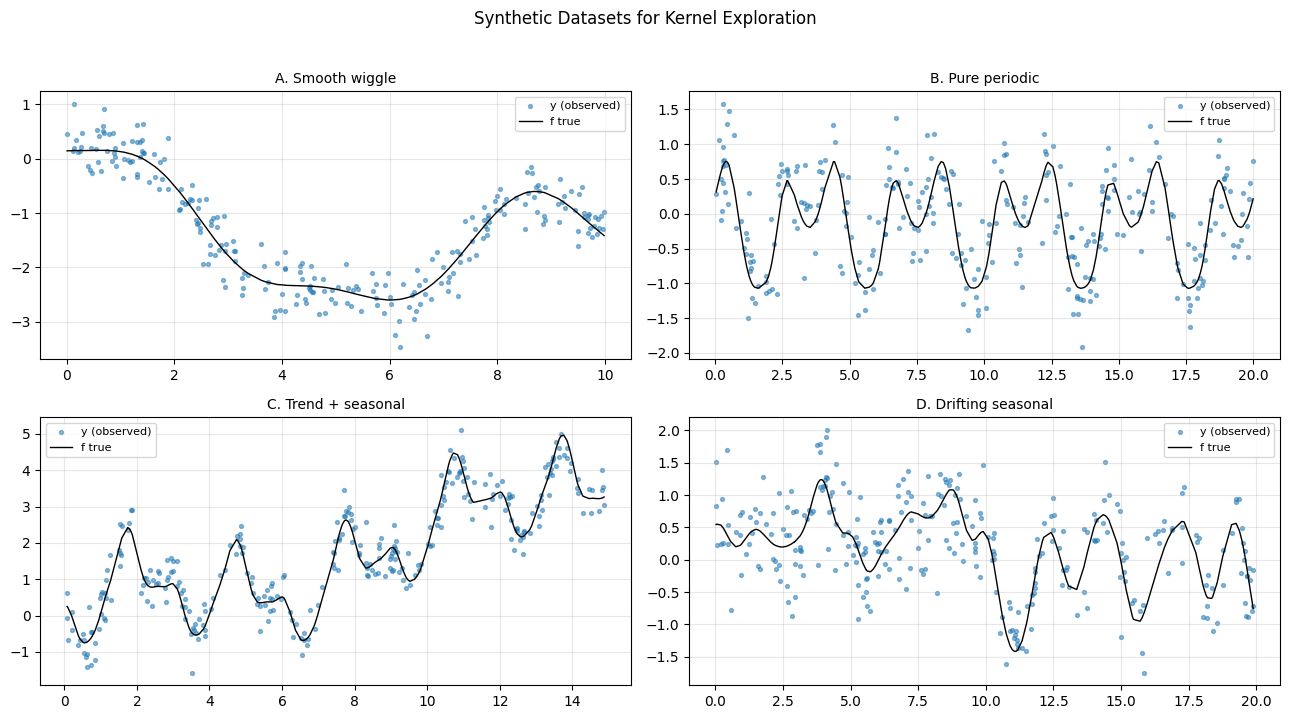

In [28]:
# Load synthetic datasets
import os

SYNTH_DIR = './data/synthetic'
datasets = {
    'A. Smooth wiggle': 'A_smooth',
    'B. Pure periodic': 'B_periodic',
    'C. Trend + seasonal': 'C_trend_plus_seasonal',
    'D. Drifting seasonal': 'D_drifting_seasonal',
}

synth_data = {}
for label, key in datasets.items():
    synth_data[label] = pd.read_csv(os.path.join(SYNTH_DIR, f'{key}.csv'))

# Plot all four datasets
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (label, df_s) in zip(axes.flat, synth_data.items()):
    ax.scatter(df_s.x, df_s.y, s=8, alpha=0.5, color='tab:blue', label='y (observed)')
    ax.plot(df_s.x, df_s.f_true, color='black', lw=1.0, label='f true')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle('Synthetic Datasets for Kernel Exploration', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

<a id="rbf-demo"></a>
### RBF Kernel: Smooth Functions

The RBF (squared exponential) kernel is the default choice for GPs. It assumes the function is infinitely differentiable, producing very smooth predictions. The **lengthscale** $\ell$ controls how quickly correlations decay: small $\ell$ produces wiggly fits, large $\ell$ produces smooth fits.

Below we fit the RBF kernel to Dataset A (smooth) and Dataset B (periodic) to see where it succeeds and where it fails.

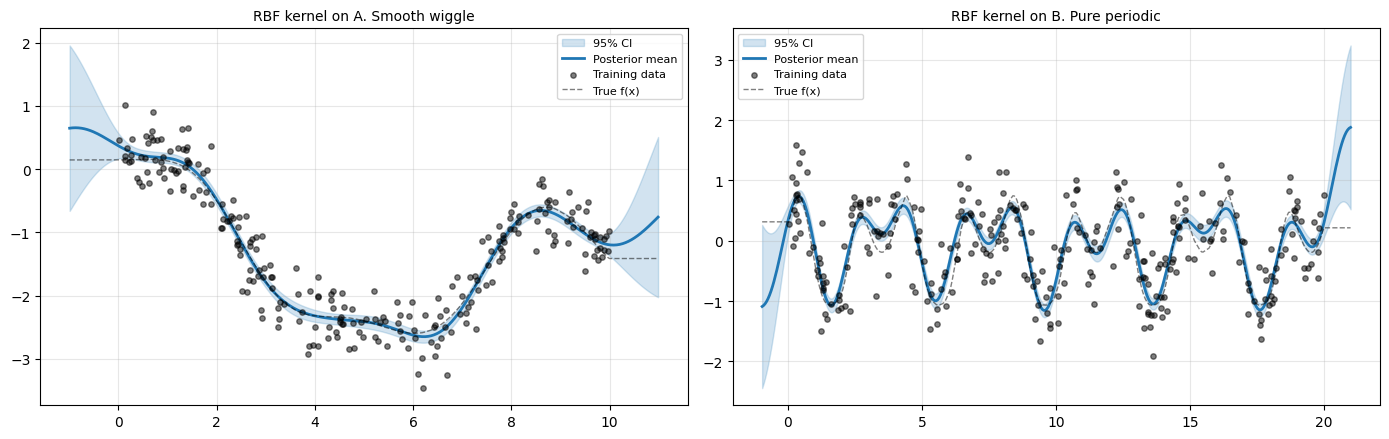

In [29]:
# Helper function for plotting GP fits
def plot_gp_fit(x_train, y_train, x_test, mu, std, f_true=None, title='', ax=None):
    """Plot GP posterior mean, uncertainty band, training data, and optionally the true function."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(x_test, mu - 2*std, mu + 2*std, alpha=0.2, color='tab:blue', label='95% CI')
    ax.plot(x_test, mu, color='tab:blue', lw=2, label='Posterior mean')
    ax.scatter(x_train, y_train, s=15, color='black', alpha=0.5, zorder=3, label='Training data')
    if f_true is not None:
        ax.plot(x_test, f_true, color='black', lw=1, alpha=0.5, linestyle='--', label='True f(x)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)
    return ax

# --- RBF on Dataset A (smooth) vs Dataset B (periodic) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, (label, ds_key) in zip(axes, [('A. Smooth wiggle', 'A. Smooth wiggle'),
                                       ('B. Pure periodic', 'B. Pure periodic')]):
    df_s = synth_data[ds_key]
    x_tr = df_s.x.values.reshape(-1, 1)
    y_tr = df_s.y.values
    
    # Dense test grid (extend beyond training range to test extrapolation)
    x_te = np.linspace(df_s.x.min() - 1, df_s.x.max() + 1, 400).reshape(-1, 1)
    
    mu, std = gp_predict(x_tr, y_tr, x_te, kernel_rbf, noise_var=0.04,
                         variance=1.0, lengthscale=1.0)
    
    # Interpolate true function onto test grid
    f_interp = np.interp(x_te.ravel(), df_s.x.values, df_s.f_true.values)
    
    plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu, std,
                f_true=f_interp, title=f'RBF kernel on {label}', ax=ax)

fig.tight_layout()
plt.show()

**Observations:** The RBF kernel fits Dataset A well -- the posterior mean tracks the true function, and the uncertainty band widens in gaps between observations. On Dataset B, however, the RBF captures the pattern *within* the training range but **cannot extrapolate the cycles** beyond the data. At the edges, the mean reverts to zero and uncertainty explodes. This is because the RBF kernel assumes "far apart = uncorrelated," so it has no mechanism to predict repeating structure.

<a id="periodic-demo"></a>
### Periodic Kernel: Repeating Cycles

The Periodic kernel explicitly encodes cyclical structure with a known period $p$. It assumes that points separated by exactly one period are as correlated as points at the same location. This makes it ideal for seasonal data (temperature, CO2, sales cycles) where the pattern repeats indefinitely.

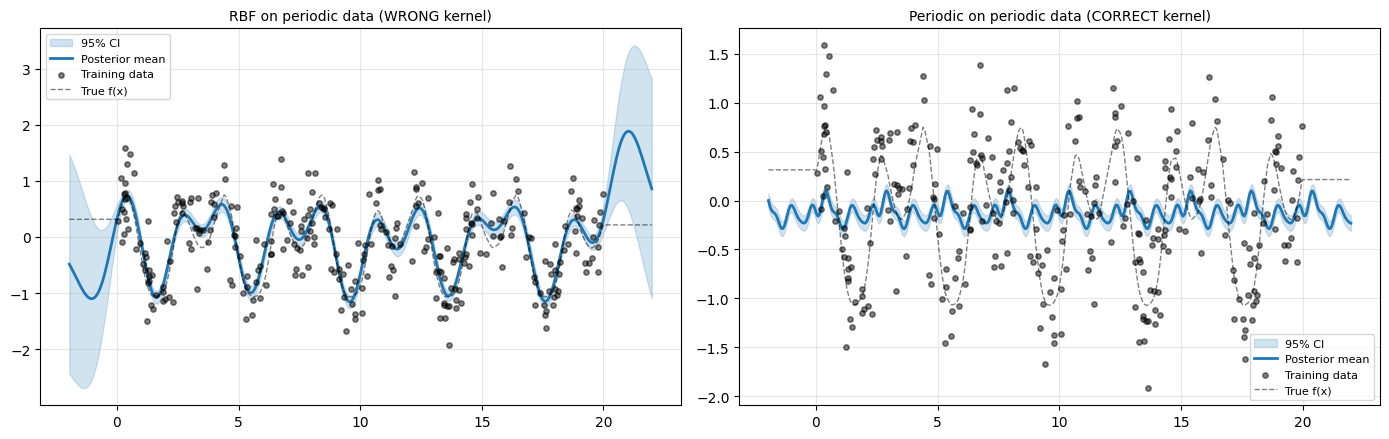

In [30]:
# --- Periodic kernel on Dataset B (periodic) vs RBF on the same ---
df_b = synth_data['B. Pure periodic']
x_tr = df_b.x.values.reshape(-1, 1)
y_tr = df_b.y.values
x_te = np.linspace(df_b.x.min() - 2, df_b.x.max() + 2, 400).reshape(-1, 1)
f_interp = np.interp(x_te.ravel(), df_b.x.values, df_b.f_true.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# RBF (wrong kernel)
mu_rbf, std_rbf = gp_predict(x_tr, y_tr, x_te, kernel_rbf, noise_var=0.04,
                              variance=1.0, lengthscale=1.0)
plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu_rbf, std_rbf,
            f_true=f_interp, title='RBF on periodic data (WRONG kernel)', ax=axes[0])

# Periodic (correct kernel)
mu_per, std_per = gp_predict(x_tr, y_tr, x_te, kernel_periodic, noise_var=0.04,
                              variance=1.0, lengthscale=1.0, period=2.5)
plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu_per, std_per,
            f_true=f_interp, title='Periodic on periodic data (CORRECT kernel)', ax=axes[1])

fig.tight_layout()
plt.show()

**Observations:** The Periodic kernel extrapolates the cycles cleanly beyond the training range, while the RBF's predictions collapse to the prior mean. This demonstrates the fundamental principle: **the kernel IS the assumption**. The Periodic kernel "knows" that the same phase of the cycle should produce the same value, regardless of absolute distance.

<a id="matern-demo"></a>
### Matern Kernel: Controlling Smoothness

The Matern family provides a middle ground between the infinitely smooth RBF and rough processes. The Matern 3/2 kernel produces functions that are once-differentiable -- smooth enough to be continuous but allowing sharper transitions than the RBF. This makes it popular for modeling physical processes like temperature, wind speed, or terrain elevation.

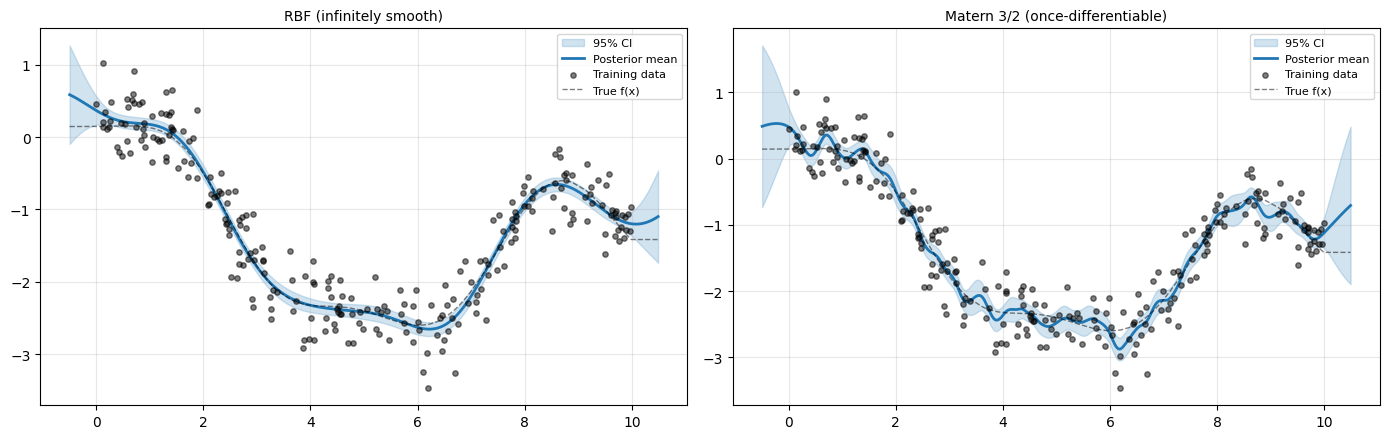

In [31]:
# --- RBF vs Matern 3/2 on Dataset A ---
df_a = synth_data['A. Smooth wiggle']
x_tr = df_a.x.values.reshape(-1, 1)
y_tr = df_a.y.values
x_te = np.linspace(df_a.x.min() - 0.5, df_a.x.max() + 0.5, 400).reshape(-1, 1)
f_interp = np.interp(x_te.ravel(), df_a.x.values, df_a.f_true.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# RBF
mu_rbf, std_rbf = gp_predict(x_tr, y_tr, x_te, kernel_rbf, noise_var=0.04,
                              variance=1.0, lengthscale=1.0)
plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu_rbf, std_rbf,
            f_true=f_interp, title='RBF (infinitely smooth)', ax=axes[0])

# Matern 3/2
mu_m32, std_m32 = gp_predict(x_tr, y_tr, x_te, kernel_matern32, noise_var=0.04,
                              variance=1.0, lengthscale=1.0)
plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu_m32, std_m32,
            f_true=f_interp, title='Matern 3/2 (once-differentiable)', ax=axes[1])

fig.tight_layout()
plt.show()

**Observations:** Both kernels fit the smooth data well, but the Matern 3/2 posterior mean is slightly less smooth -- it allows small kinks that the RBF cannot produce. For truly smooth data (Dataset A), both work. For rougher real-world data (e.g., terrain, financial time series), the Matern family is often more appropriate because the infinite smoothness of the RBF is unrealistic.

**Application examples:** The Matern kernel is widely used in geostatistics (kriging), robotics (terrain mapping), and environmental science where physical processes produce continuous but not perfectly smooth surfaces.

<a id="linear-demo"></a>
### Linear Kernel: Global Trends

The Linear kernel $k(x, x') = \sigma^2 x \cdot x'$ is equivalent to Bayesian linear regression. It assumes the function is a straight line (plus noise). While simple, the Linear kernel is powerful as a **component** in additive or multiplicative kernel compositions, where it captures global trends while other kernels handle local structure.

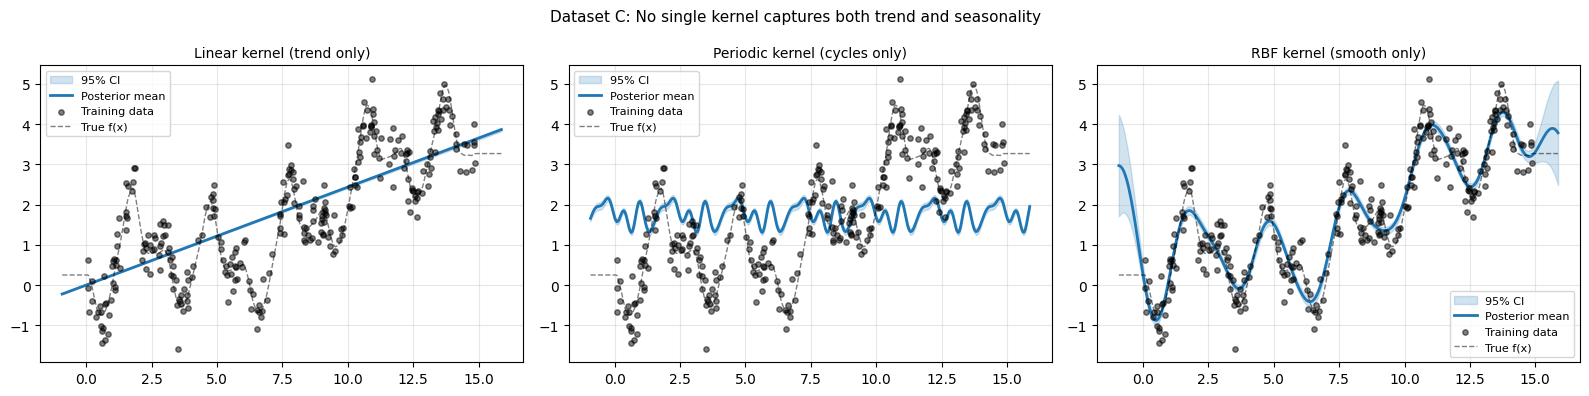

In [32]:
# --- Linear kernel on Dataset C (trend + seasonal) ---
# The linear kernel can only capture the trend, not the cycles
df_c = synth_data['C. Trend + seasonal']
x_tr = df_c.x.values.reshape(-1, 1)
y_tr = df_c.y.values
x_te = np.linspace(df_c.x.min() - 1, df_c.x.max() + 1, 400).reshape(-1, 1)
f_interp = np.interp(x_te.ravel(), df_c.x.values, df_c.f_true.values)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Linear only
mu_lin, std_lin = gp_predict(x_tr, y_tr, x_te, kernel_linear, noise_var=0.04,
                              variance=0.5)
plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu_lin, std_lin,
            f_true=f_interp, title='Linear kernel (trend only)', ax=axes[0])

# Periodic only
mu_per, std_per = gp_predict(x_tr, y_tr, x_te, kernel_periodic, noise_var=0.04,
                              variance=1.0, lengthscale=1.0, period=2.5)
plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu_per, std_per,
            f_true=f_interp, title='Periodic kernel (cycles only)', ax=axes[1])

# RBF only
mu_rbf, std_rbf = gp_predict(x_tr, y_tr, x_te, kernel_rbf, noise_var=0.04,
                              variance=1.0, lengthscale=1.0)
plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu_rbf, std_rbf,
            f_true=f_interp, title='RBF kernel (smooth only)', ax=axes[2])

fig.suptitle('Dataset C: No single kernel captures both trend and seasonality', fontsize=11)
fig.tight_layout()
plt.show()

**Observations:** No single kernel captures Dataset C's structure. The Linear kernel finds the upward trend but misses the oscillation. The Periodic kernel captures cycles but has no mechanism for drift. The RBF smooths everything together, producing a reasonable interpolation but poor extrapolation. This motivates **kernel composition**.

<a id="kernel-composition"></a>
### Kernel Composition: Addition and Multiplication

Kernels can be combined to build richer models:

- **Addition** ($K_1 + K_2$): The function is a *sum* of independent components, $f = f_1 + f_2$. Each component captures a different structural pattern. Similarity can arise from *either* component.
- **Multiplication** ($K_1 \times K_2$): The components *modulate* each other. For example, $\text{RBF} \times \text{Periodic}$ produces a periodic pattern whose amplitude varies smoothly over time.

Below we demonstrate both on Datasets C and D.

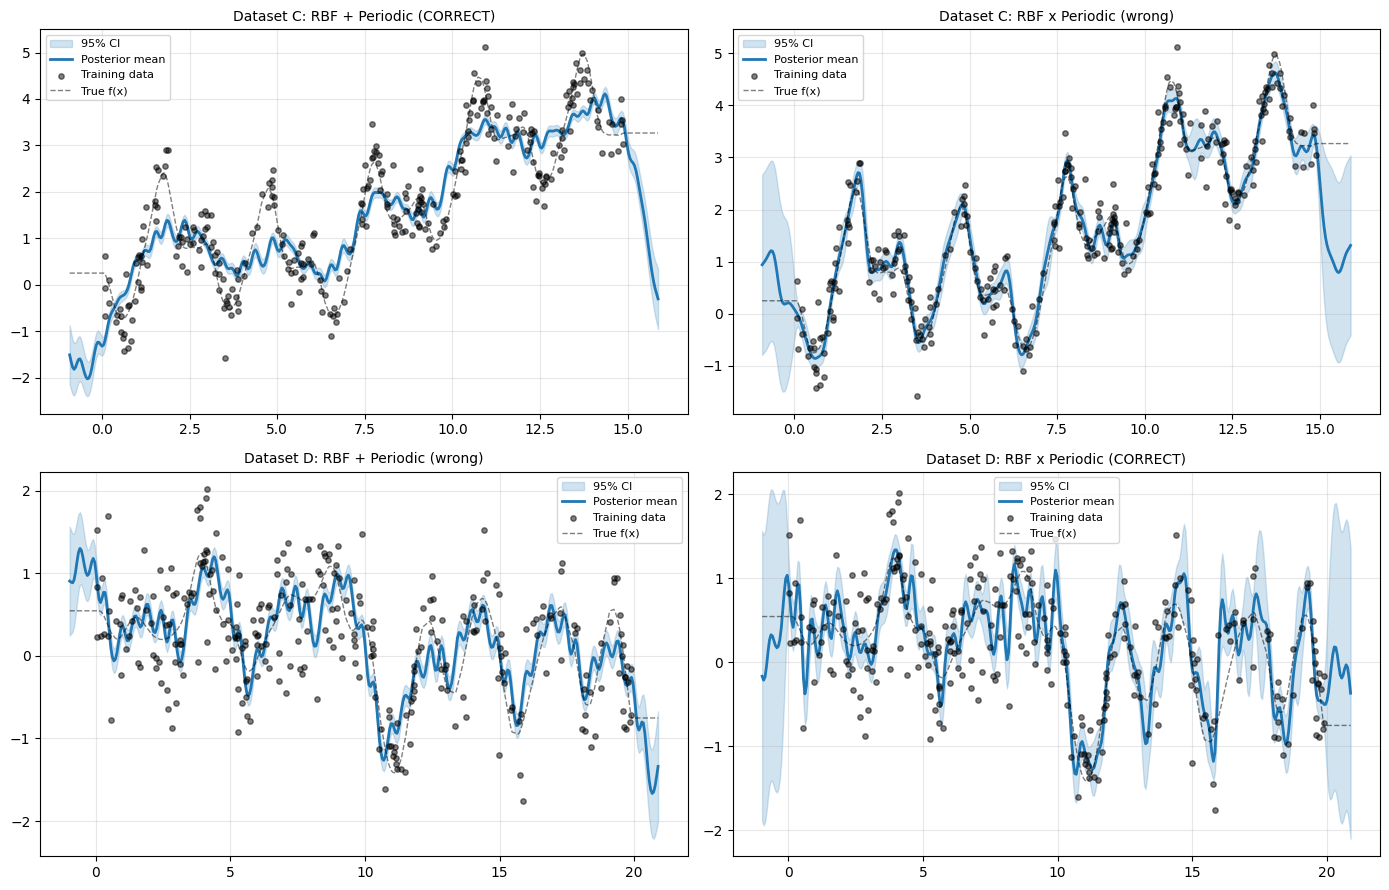

In [33]:
# --- Kernel composition: Addition vs Multiplication ---

# Composed kernel functions
def kernel_rbf_plus_periodic(X1, X2, variance=1.0, lengthscale=1.0, period=2.5):
    """RBF + Periodic: captures smooth trend AND repeating cycles."""
    return kernel_rbf(X1, X2, variance=variance, lengthscale=lengthscale) + \
           kernel_periodic(X1, X2, variance=variance, lengthscale=0.5, period=period)

def kernel_rbf_times_periodic(X1, X2, variance=1.0, lengthscale=1.0, period=2.5):
    """RBF * Periodic: periodic pattern whose amplitude varies smoothly."""
    return kernel_rbf(X1, X2, variance=1.0, lengthscale=lengthscale) * \
           kernel_periodic(X1, X2, variance=variance, lengthscale=0.5, period=period)

# --- Dataset C: RBF + Periodic (additive composition) ---
df_c = synth_data['C. Trend + seasonal']
x_tr = df_c.x.values.reshape(-1, 1)
y_tr = df_c.y.values
x_te = np.linspace(df_c.x.min() - 1, df_c.x.max() + 1, 400).reshape(-1, 1)
f_interp_c = np.interp(x_te.ravel(), df_c.x.values, df_c.f_true.values)

# --- Dataset D: RBF * Periodic vs RBF + Periodic ---
df_d = synth_data['D. Drifting seasonal']
x_tr_d = df_d.x.values.reshape(-1, 1)
y_tr_d = df_d.y.values
x_te_d = np.linspace(df_d.x.min() - 1, df_d.x.max() + 1, 400).reshape(-1, 1)
f_interp_d = np.interp(x_te_d.ravel(), df_d.x.values, df_d.f_true.values)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Row 1: Dataset C
mu_add_c, std_add_c = gp_predict(x_tr, y_tr, x_te, kernel_rbf_plus_periodic, noise_var=0.04,
                                  variance=1.0, lengthscale=2.0, period=2.5)
plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu_add_c, std_add_c,
            f_true=f_interp_c, title='Dataset C: RBF + Periodic (CORRECT)', ax=axes[0, 0])

mu_mul_c, std_mul_c = gp_predict(x_tr, y_tr, x_te, kernel_rbf_times_periodic, noise_var=0.04,
                                  variance=1.0, lengthscale=2.0, period=2.5)
plot_gp_fit(x_tr.ravel(), y_tr, x_te.ravel(), mu_mul_c, std_mul_c,
            f_true=f_interp_c, title='Dataset C: RBF x Periodic (wrong)', ax=axes[0, 1])

# Row 2: Dataset D
mu_add_d, std_add_d = gp_predict(x_tr_d, y_tr_d, x_te_d, kernel_rbf_plus_periodic, noise_var=0.04,
                                  variance=1.0, lengthscale=2.0, period=2.5)
plot_gp_fit(x_tr_d.ravel(), y_tr_d, x_te_d.ravel(), mu_add_d, std_add_d,
            f_true=f_interp_d, title='Dataset D: RBF + Periodic (wrong)', ax=axes[1, 0])

mu_mul_d, std_mul_d = gp_predict(x_tr_d, y_tr_d, x_te_d, kernel_rbf_times_periodic, noise_var=0.04,
                                  variance=1.0, lengthscale=2.0, period=2.5)
plot_gp_fit(x_tr_d.ravel(), y_tr_d, x_te_d.ravel(), mu_mul_d, std_mul_d,
            f_true=f_interp_d, title='Dataset D: RBF x Periodic (CORRECT)', ax=axes[1, 1])

fig.tight_layout()
plt.show()

**Observations:**
- **Dataset C (trend + seasonal):** RBF + Periodic correctly captures both the upward trend and the repeating cycles. The multiplicative kernel struggles because it enforces that the cycle amplitude must vary with the trend, which isn't the case here.
- **Dataset D (drifting seasonal):** RBF x Periodic correctly captures the changing cycle shape. The additive kernel enforces a rigid repeating pattern that cannot adapt to the evolving amplitude.

The key insight: **addition = independent behaviors stacked together; multiplication = one behavior modulating another.** Choose based on the generative story you believe about the data.

<a id="kernel-summary"></a>
### Summary of Kernel Properties

| Kernel | Smoothness | Extrapolation | Best Use Case | Real-World Examples |
|:---|:---|:---|:---|:---|
| **RBF** | Infinitely smooth | Reverts to mean | Smooth spatial/temporal fields | Housing prices, temperature fields, elevation maps |
| **Matern 3/2** | Once-differentiable | Reverts to mean | Rough natural processes | Wind speed, precipitation, terrain roughness |
| **Periodic** | Smooth within cycle | Extrapolates cycles forever | Seasonal/cyclical data | CO2 levels, retail sales, tidal patterns |
| **Linear** | N/A (global trend) | Extrapolates linearly | Trend components | Income vs. price, population growth |
| **RBF + Periodic** | Mixed | Trend + cycle extrapolation | Trend with seasonality | Mauna Loa CO2, stock market seasonality |
| **RBF x Periodic** | Mixed | Modulated cycles | Evolving periodic patterns | Climate change effects, economic cycles |

**Connection to our California Housing model:** In the spatial model above, we used the RBF kernel because housing prices vary smoothly over geography (no periodicity in space). In the next section, we extend this with an additive kernel (RBF + Linear) that combines spatial smoothness with a linear income effect -- the same composition principle demonstrated on Dataset C, but applied to real data with a different component kernel.

<a id="model-extension"></a>
## Model Extension: Additive Kernel (Spatial + Income)

<a id="motivation"></a>
### Motivation

The spatial-only GP model captures geographic trends but leaves substantial residual variance unexplained. Much of this variance is driven by socio-economic factors that vary within the same geographic area. Median income (`MedInc`) is one of the strongest predictors of housing value, and incorporating it should reduce the noise variance $\sigma$ and improve predictive accuracy.

However, GPs scale as $O(n^3)$ in computation and $O(n^2)$ in memory, so adding many features is expensive. We therefore extend the model with just one additional predictor, using an **additive kernel** structure that decomposes the function into interpretable spatial and income components.

<a id="kernel-specification"></a>
### Kernel Specification

In this model, we use an **additive kernel** that combines two components:

- A **spatial RBF (squared exponential) kernel** on coordinates (Latitude, Longitude), the same kernel used in the spatial-only model
- A **linear kernel** on median income (MedInc)

The overall covariance function is:

$$
K = K_{\text{loc}} + K_{\text{inc}} + \sigma^2 I
$$

---

#### Spatial RBF Kernel

$$
k_{\text{loc}}(x_i, x_j) = \alpha_{\text{loc}}^2 \exp\left(-\frac{\|x_i - x_j\|^2}{2\rho_{\text{loc}}^2}\right)
$$

This kernel assumes that **housing prices vary smoothly over space**, meaning nearby locations tend to have similar values.

---

#### Linear Kernel on MedInc

$$
k_{\text{inc}}(m_i, m_j) = \alpha_{\text{inc}}^2 \, m_i m_j
$$

This kernel captures a **linear relationship between median income and house value**, expressing the assumption that block groups with higher median income tend to have higher housing prices.

---

#### Priors on Hyperparameters

We place weakly informative lognormal priors on all four hyperparameters:

$$
\alpha_{\text{loc}} \sim \text{LogNormal}(0,\; 0.5)
$$

$$
\rho_{\text{loc}} \sim \text{LogNormal}(0,\; 0.5)
$$

$$
\alpha_{\text{inc}} \sim \text{LogNormal}(0,\; 0.5)
$$

$$
\sigma \sim \text{LogNormal}(-1,\; 0.5)
$$

These are the same prior families used in the spatial-only model. The new parameter $\alpha_{\text{inc}}$ controls the amplitude of the income effect and receives the same prior as the spatial amplitude, allowing the data to determine the relative contribution of each kernel component.

---

#### Why These Kernels?

- The **RBF kernel** models spatial smoothness, which is a natural assumption for geographic data.
- The **linear kernel** introduces a global trend based on income, which is known to be a strong predictor of housing value.

Together, they allow the model to capture both local spatial variation and global socio-economic effects.

---

#### Why Additive Rather Than Multiplicative?

The additive structure $K = K_{\text{loc}} + K_{\text{inc}}$ decomposes the housing price function as:

$$
f = f_{\text{spatial}} + f_{\text{income}}
$$

This means similarity between two block groups' housing values can arise from *either* being geographically close *or* having similar income levels. A multiplicative kernel $K = K_{\text{loc}} \cdot K_{\text{inc}}$ would instead require *both* spatial proximity and income similarity for strong correlation. The additive structure better reflects our belief that location and income are independently informative predictors of housing price.

<a id="extension-preprocessing"></a>
### Preprocessing & Fitting

We repeat the same preprocessing pipeline, now including `MedInc` as an additional feature. Since coordinates and income are on fundamentally different scales, we apply separate `StandardScaler` instances to each feature group to ensure the kernel distance calculations are well-conditioned.

In [ ]:
df = cali_house[['Latitude', 'Longitude', 'MedInc', 'MedHouseVal']].sample(300, random_state=42).reset_index(drop=True)
df_stan = df.reset_index(drop=True)

df_stan.head()

,Latitude,Longitude,MedInc,MedHouseVal
0,36.06,-119.01,1.6812,0.47700
1,35.14,-119.46,2.5313,0.45800
2,37.80,-122.44,3.4801,5.00001
3,34.28,-118.72,5.7376,2.18600
4,36.62,-121.93,3.7250,2.78000


In [ ]:
train_df, test_df = train_test_split(df_stan, test_size=0.2, random_state=42)

Coordinates and median income are on fundamentally different scales, so we use separate `StandardScaler` instances for each feature group. All scalers are fit on the training set only.

In [ ]:
# Choose features
coord_cols = ["Latitude", "Longitude"]
inc_col = "MedInc"
y_col = "MedHouseVal"


# scalers
from sklearn.preprocessing import StandardScaler
loc_scaler = StandardScaler()
inc_scaler = StandardScaler()
y_scaler = StandardScaler()


# Split first, then fit scalers on training data only
X_loc_train_raw = train_df[coord_cols].to_numpy()
X_loc_test_raw = test_df[coord_cols].to_numpy()

x_inc_train_raw = train_df[[inc_col]].to_numpy()
x_inc_test_raw = test_df[[inc_col]].to_numpy()

y_train_raw = train_df[y_col].to_numpy()
y_test_raw = test_df[y_col].to_numpy()

# scaled
X_loc_train_scaled = loc_scaler.fit_transform(X_loc_train_raw)
X_loc_test_scaled = loc_scaler.transform(X_loc_test_raw)

x_inc_train_scaled = inc_scaler.fit_transform(x_inc_train_raw).ravel()
x_inc_test_scaled = inc_scaler.transform(x_inc_test_raw).ravel()

y_train_scaled = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

print(X_loc_train_scaled.shape, X_loc_test_scaled.shape)
print(x_inc_train_scaled.shape, x_inc_test_scaled.shape)
print(y_train_scaled.shape, y_test_scaled.shape)

(240, 2) (60, 2)
(240,) (60,)
(240,) (60,)


#### Fitting the Additive Model

We compile and fit the additive GP model in Stan using the same sampling configuration (4 chains, 1000 warmup, 1000 sampling iterations).

In [ ]:
path = './stan/gp_california_additive.stan'

# 2. have CmdStanPy reading it
model = CmdStanModel(stan_file=path)


stan_data = {
    "N_train": X_loc_train_scaled.shape[0],
    "N_test": X_loc_test_scaled.shape[0],
    "D_loc": X_loc_train_scaled.shape[1],
    "X_loc_train": X_loc_train_scaled,
    "X_loc_test": X_loc_test_scaled,
    "x_inc_train": x_inc_train_scaled.ravel(),
    "x_inc_test": x_inc_test_scaled.ravel(),
    "y_train": y_train_scaled.ravel(),
}


# 3. fitting
fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_console=True
)

Due to the long runtime of HMC sampling for the additive GP model, we save the posterior draws as compressed CSVs and reload them for analysis. This avoids re-running the sampler each time the notebook is opened.

In [ ]:
# Save MCMC results to ./results/ (run once after fitting)
import os, zipfile

RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save CmdStan CSV files
fit.save_csvfiles(dir=RESULTS_DIR)

# Compress into a zip archive
zip_path = os.path.join(RESULTS_DIR, 'additive_fit.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir(RESULTS_DIR)):
        if fname.endswith('.csv'):
            fpath = os.path.join(RESULTS_DIR, fname)
            zf.write(fpath, fname)
            os.remove(fpath)  # remove uncompressed CSV after zipping

print(f"Saved to {zip_path} ({os.path.getsize(zip_path) / 1e6:.1f} MB)")

To reload results without re-running the sampler, run the cell below instead of the fitting cell above.

In [ ]:
# Reload MCMC results from compressed archive
import os, zipfile, glob, tempfile
from cmdstanpy import from_csv

zip_path = './results/additive_fit.zip'

# Extract CSVs to a temp directory and load
tmpdir = tempfile.mkdtemp()
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(tmpdir)

csv_files = sorted(glob.glob(os.path.join(tmpdir, '*.csv')))
fit = from_csv(csv_files)
print(f"Loaded {len(csv_files)} chains from {zip_path}")

<a id="extension-diagnostics"></a>
### Diagnostics

We repeat the same MCMC diagnostic checks for the additive model. The additive kernel introduces an additional hyperparameter ($\alpha_{\text{inc}}$), so we verify that all four parameters converge properly.

In [ ]:
summary_df = fit.summary()
params = ["alpha_loc", "rho_loc", "alpha_inc", "sigma"]

print(summary_df.loc[params, ['Mean', 'StdDev', 'R_hat', 'ESS_bulk', 'ESS_tail']])

               Mean    StdDev    R_hat  ESS_bulk  ESS_tail
alpha_loc  0.961581  0.301883  1.00171   2790.32   2354.64
rho_loc    0.810062  0.301271  1.00116   2316.24   2477.68
alpha_inc  1.004300  0.472444  1.00134   3612.63   2421.48
sigma      0.621543  0.031493  1.00170   2984.66   2659.20


In [ ]:
sampler_diagnostics = fit.diagnose()
print(sampler_diagnostics)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



#### Diagnostics Interpretation

All diagnostics pass cleanly for the additive model as well. Notably, the effective sample sizes are substantially larger than the spatial-only model (ESS_bulk > 2300 for all parameters), suggesting that the additive kernel parameterization is easier for the sampler to explore. The noise standard deviation $\sigma$ drops from 0.77 to 0.62, confirming that income explains a meaningful portion of the previously unexplained variance.

#### Posterior Summaries

The table below shows the posterior summaries for the four hyperparameters of the additive model. Compared to the spatial-only model, the spatial lengthscale $\rho_{\text{loc}}$ has roughly doubled (from 0.39 to 0.81), indicating that once income is accounted for, the remaining spatial variation is smoother and longer-range.

In [ ]:
posterior = fit.draws_pd()

params_of_interest = ["alpha_loc", "rho_loc", "alpha_inc", "sigma"]
posterior_summary = summary_df.loc[
    params_of_interest,
    ['Mean', 'StdDev', '5%', '50%', '95%', 'R_hat']
]
print(posterior_summary)

               Mean    StdDev        5%       50%       95%    R_hat
alpha_loc  0.961581  0.301883  0.588746  0.899690  1.529860  1.00171
rho_loc    0.810062  0.301271  0.342272  0.807396  1.318360  1.00116
alpha_inc  1.004300  0.472444  0.442989  0.907669  1.889860  1.00134
sigma      0.621543  0.031493  0.570063  0.621045  0.674181  1.00170


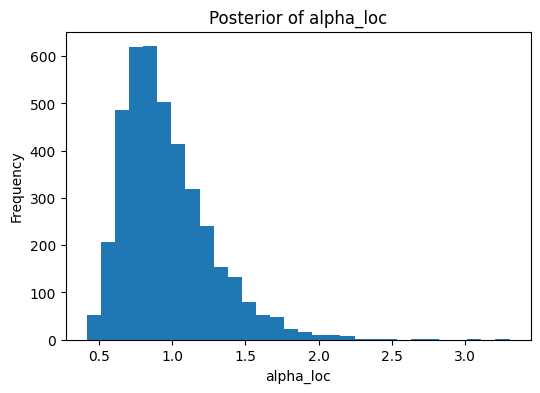

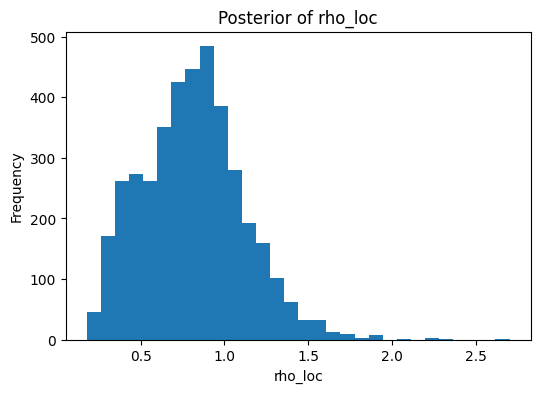

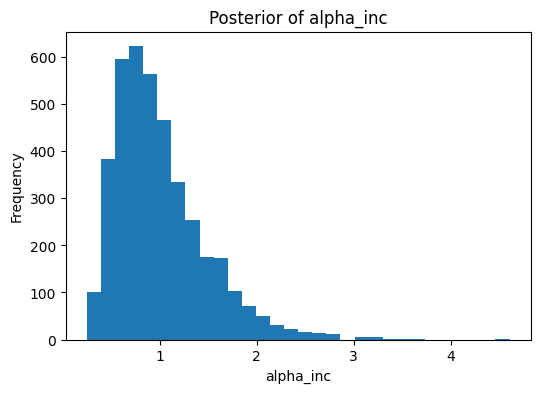

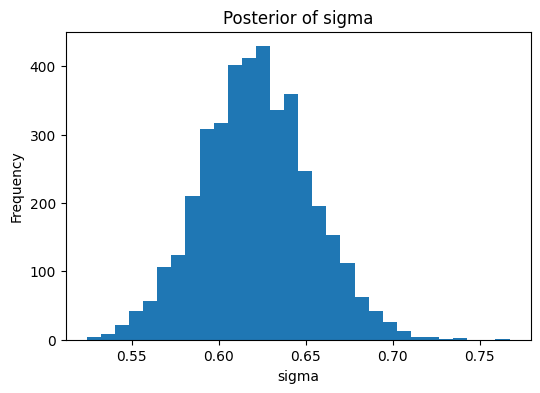

In [ ]:
for param in params_of_interest:
    plt.figure(figsize=(6, 4))
    plt.hist(posterior[param], bins=30)
    plt.title(f'Posterior of {param}')
    plt.xlabel(param)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
# Extract posterior predictive draws for test points
y_test_rep = fit.stan_variable('y_test_rep')   # shape: (draws, N_test)

# Posterior predictive mean on standardized scale
y_test_pred_mean_scaled = y_test_rep.mean(axis=0)

# Transform back to original scale
y_test_pred_mean = y_scaler.inverse_transform(
    y_test_pred_mean_scaled.reshape(-1, 1)
).ravel()

In [ ]:
print(y_test_pred_mean.min(), y_test_pred_mean.max())

0.40329048567854775 4.999905667227617


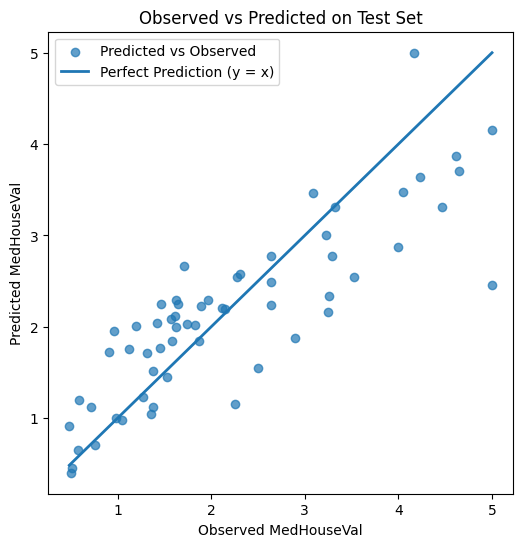

In [ ]:
plt.figure(figsize=(6, 6))

# scatter points
plt.scatter(
    y_test_raw,
    y_test_pred_mean,
    alpha=0.7,
    label='Predicted vs Observed'
)

# diagonal line (perfect prediction)
plt.plot(
    [y_test_raw.min(), y_test_raw.max()],
    [y_test_raw.min(), y_test_raw.max()],
    label='Perfect Prediction (y = x)',
    linewidth=2
)

plt.xlabel('Observed MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Observed vs Predicted on Test Set')

plt.legend()
plt.show()

<a id="extension-evaluation"></a>
### Posterior Predictive Evaluation

#### Observed vs. Predicted

The scatter plot of observed vs. predicted values shows a clear positive relationship, indicating that the model captures the overall trend in the data. Most points lie near the diagonal line, suggesting reasonable predictive accuracy.

However, there is a noticeable pattern where high-valued observations tend to be underestimated, while low-valued observations are slightly overestimated. This indicates a regression-to-the-mean effect, where the model struggles to fully capture extreme values.

Overall, the additive model performs well in capturing general patterns but exhibits limited flexibility in modeling extremes.

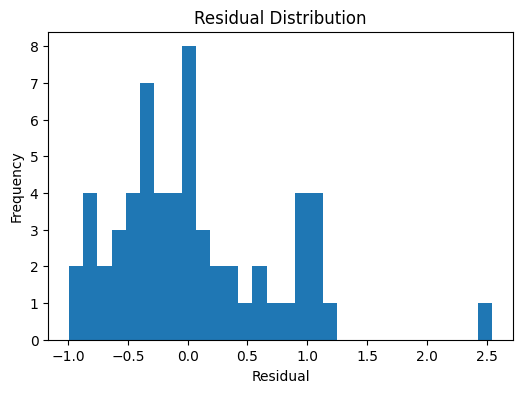

In [ ]:
residuals = y_test_raw - y_test_pred_mean

plt.figure(figsize=(6, 4))

plt.hist(residuals, bins=30)

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.show()

#### Residual Analysis

The residual distribution is centered approximately around zero, indicating that the model does not exhibit strong systematic bias overall.

However, the distribution appears slightly skewed, with a longer right tail, suggesting that some observations are underpredicted. This aligns with the scatter plot, where high-value targets tend to be underestimated.

The spread of residuals is narrower than the spatial-only model, confirming that the addition of income as a predictor reduces unexplained variance.

#### Posterior Predictive Check & Kernel Definitions

We define the additive kernel components in NumPy for posterior predictive visualization, then overlay posterior predictive draws against the observed test distribution.

In [ ]:
# kernels for posterior prediction / plotting with posterior mean parameters
def rbf_kernel(X1, X2, alpha, rho):
    sqdist = (
        np.sum(X1**2, axis=1)[:, None]
        + np.sum(X2**2, axis=1)[None, :]
        - 2 * X1 @ X2.T
    )
    return (alpha**2) * np.exp(-0.5 * sqdist / (rho**2))


def linear_income_kernel(x1, x2, alpha_inc):
    x1 = np.asarray(x1).reshape(-1, 1)
    x2 = np.asarray(x2).reshape(-1, 1)
    return (alpha_inc**2) * (x1 @ x2.T)


def additive_kernel(Xloc1, Xloc2, xinc1, xinc2, alpha_loc, rho_loc, alpha_inc):
    K_loc = rbf_kernel(Xloc1, Xloc2, alpha_loc, rho_loc)
    K_inc = linear_income_kernel(xinc1, xinc2, alpha_inc)
    return K_loc + K_inc

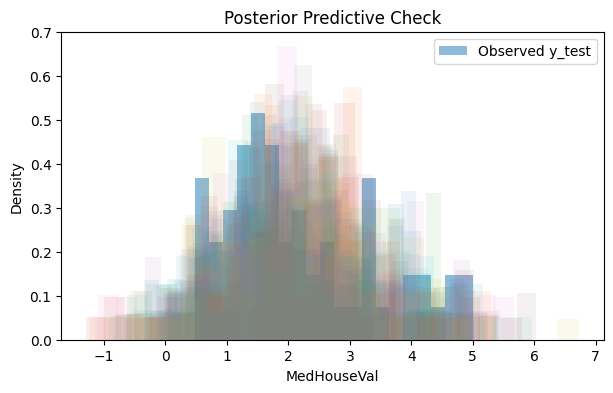

In [ ]:
# a few posterior predictive draws and transform back
num_draws_to_plot = 30
draw_indices = np.random.choice(y_test_rep.shape[0], size=num_draws_to_plot, replace=False)

plt.figure(figsize=(7, 4))
plt.hist(y_test_raw, bins=20, alpha=0.5, density=True, label="Observed y_test")

for idx in draw_indices:
    y_rep_original = y_scaler.inverse_transform(
        y_test_rep[idx].reshape(-1, 1)
    ).ravel()
    plt.hist(y_rep_original, bins=20, alpha=0.08, density=True)

plt.xlabel('MedHouseVal')
plt.ylabel('Density')
plt.title('Posterior Predictive Check')
plt.legend()
plt.show()

The posterior predictive check shows that the simulated distributions broadly align with the observed data, particularly in the central region, indicating that the model captures the overall structure of the data well.

However, the predictive distributions exhibit slightly heavier tails and greater spread compared to the observed data, suggesting that the model may overestimate variability, especially in higher-value regions. This is consistent with earlier observations from the scatter and residual plots, where extreme values are not fully captured.

<a id="extension-heatmaps"></a>
### Spatial Heatmaps

#### Predictive Mean Surface

The spatial surface is evaluated at the average level of median income, isolating the spatial effect captured by the model. This allows us to compare how the additive model's spatial component differs from the spatial-only model.

The spatial surface shows clear regional variation, with higher predicted house values concentrated in specific areas and lower values in others. This indicates that the model successfully captures spatial structure in the data, even after accounting for income effects.

In [ ]:
# my grid
lon_min, lon_max = df['Longitude'].min(), df['Longitude'].max()
lat_min, lat_max = df['Latitude'].min(), df['Latitude'].max()

lon_grid = np.linspace(lon_min, lon_max, 80)
lat_grid = np.linspace(lat_min, lat_max, 80)

lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

X_grid = np.column_stack([lat_mesh.ravel(), lon_mesh.ravel()])
X_grid_scaled = loc_scaler.transform(X_grid)

In [ ]:
# do some math
alpha_loc = 0.961581
rho_loc = 0.810062
alpha_inc = 1.004300
sigma = 0.621543

jitter = 1e-5


K = additive_kernel(
    X_loc_train_scaled, X_loc_train_scaled,
    x_inc_train_scaled, x_inc_train_scaled,
    alpha_loc, rho_loc, alpha_inc,
)
K[np.diag_indices_from(K)] += sigma**2 + jitter

K_s = additive_kernel(
    X_loc_train_scaled, X_loc_test_scaled,
    x_inc_train_scaled, x_inc_test_scaled,
    alpha_loc, rho_loc, alpha_inc,
)

K_ss = additive_kernel(
    X_loc_test_scaled, X_loc_test_scaled,
    x_inc_test_scaled, x_inc_test_scaled,
    alpha_loc, rho_loc, alpha_inc,
)
K_ss[np.diag_indices_from(K_ss)] += jitter

alpha_vec = np.linalg.solve(K, y_train_scaled)
f_test_mean_scaled = K_s.T @ alpha_vec
K_pred = K_ss - K_s.T @ np.linalg.solve(K, K_s)
K_pred[np.diag_indices_from(K_pred)] += sigma**2 + jitter

f_test_mean = y_scaler.inverse_transform(f_test_mean_scaled.reshape(-1, 1)).ravel()
f_test_sd_scaled = np.sqrt(np.maximum(np.diag(K_pred), 0))
f_test_sd = f_test_sd_scaled * y_scaler.scale_[0]

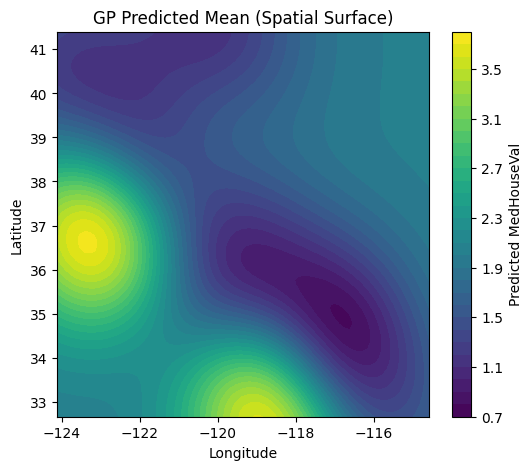

In [ ]:
# Predictive Mean Surface heatmap
med_inc_mean = x_inc_train_scaled.mean()
x_inc_grid = np.full(X_grid_scaled.shape[0], med_inc_mean)

K_s_grid = additive_kernel(
    X_loc_train_scaled, X_grid_scaled,
    x_inc_train_scaled, x_inc_grid,
    alpha_loc, rho_loc, alpha_inc
)

f_grid_scaled = K_s_grid.T @ alpha_vec

f_grid = y_scaler.inverse_transform(f_grid_scaled.reshape(-1, 1)).ravel()


mean_map = f_grid.reshape(lat_mesh.shape)

plt.figure(figsize=(6, 5))

contour = plt.contourf(
    lon_mesh,
    lat_mesh,
    mean_map,
    levels=30
)

plt.colorbar(contour, label="Predicted MedHouseVal")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GP Predicted Mean (Spatial Surface)")

plt.show()

The spatial surface shows clear regional variation, with higher predicted house values concentrated in specific areas and lower values in others. This indicates that the model successfully captures spatial structure in the data.

#### Predictive Uncertainty Surface

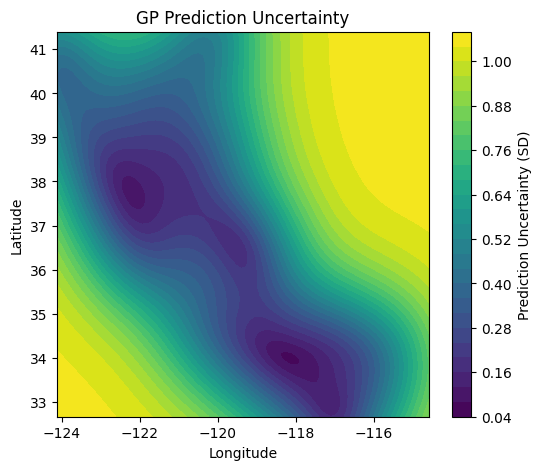

In [ ]:
# uncertainty
K_ss_grid = additive_kernel(
    X_grid_scaled, X_grid_scaled,
    x_inc_grid, x_inc_grid,
    alpha_loc, rho_loc, alpha_inc
)

K_ss_grid[np.diag_indices_from(K_ss_grid)] += jitter

K_pred_grid = K_ss_grid - K_s_grid.T @ np.linalg.solve(K, K_s_grid)

sd_grid_scaled = np.sqrt(np.maximum(np.diag(K_pred_grid), 0))
sd_grid = sd_grid_scaled * y_scaler.scale_[0]

sd_map = sd_grid.reshape(lat_mesh.shape)

plt.figure(figsize=(6, 5))

contour = plt.contourf(
    lon_mesh,
    lat_mesh,
    sd_map,
    levels=30
)

plt.colorbar(contour, label="Prediction Uncertainty (SD)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GP Prediction Uncertainty")

plt.show()

The uncertainty map shows lower prediction uncertainty in regions with more data coverage and higher uncertainty near the boundaries. This is consistent with Gaussian Process behavior, where uncertainty increases in regions farther from observed data.

<a id="what-we-learned"></a>
## What We Learned

This tutorial demonstrated Gaussian Process regression as a fully Bayesian, nonparametric approach to spatial prediction. Several key takeaways emerged:

**1. GPs provide principled uncertainty quantification.** Unlike point-prediction methods, the GP posterior yields both a predictive mean and a full covariance structure. The uncertainty heatmaps showed that the model "knows what it doesn't know" -- predictions are confident near observed data and uncertain in sparse regions, without any ad-hoc calibration.

**2. Kernel choice encodes structural assumptions.** The RBF kernel enforces spatial smoothness, producing continuous heatmaps rather than jagged predictions. The linear kernel on income captures a global trend. The additive combination $K_{\text{loc}} + K_{\text{inc}}$ decomposes the function into interpretable components, and the posterior hyperparameters reveal how much variance each component explains.

**3. Adding features improves the model, but GPs scale poorly.** Incorporating median income reduced the noise variance $\sigma$ from 0.77 to 0.62 and doubled the spatial lengthscale, meaning the spatial component became smoother once income was accounted for. However, exact GP inference scales as $O(n^3)$, which limited us to 240 training points. Scaling to the full 20,640-point dataset would require approximate methods (e.g., sparse/inducing-point GPs or variational inference).

**4. Fully Bayesian inference over hyperparameters matters.** By sampling $(\alpha, \rho, \sigma)$ with HMC rather than optimizing point estimates, we marginalized over hyperparameter uncertainty. This produced more honest predictive intervals and avoided overfitting the kernel parameters to a single configuration.

**5. Model limitations are visible in diagnostics.** The regression-to-the-mean pattern in residual plots and the right-skewed residual distribution both signal that spatial location and income alone cannot capture all drivers of housing price variability. Features like housing age, room count, and proximity to employment centers would further reduce residual variance, though at the cost of increased computational burden for exact GP inference.